In [1]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_squared_error
from typing import List, Dict, Union, Optional
import warnings
warnings.filterwarnings('ignore')


In [2]:
class tree_family():
    def __init__(self, df):
        self.df = pd.read_csv(df)
    def split_df_X_Y(self, name_of_column):
        self.x = self.df.drop(name_of_column,axis=1)
        self.y = self.df[name_of_column]
    def split_train_test(self,test_size=0.3):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(self.x, self.y, test_size=test_size, stratify=None,random_state=42)
    def DecisionTreeClassifier(self,max_depth=4, bool_save = True, class_weight = "balanced"):
        

        print("DecisionTreeClassifier\n\n")
        clf = DecisionTreeClassifier(random_state = 42,max_depth = max_depth,class_weight= class_weight)
        clf.fit(self.x_train, self.y_train)
        prediction = clf.predict(self.x_test)
        tree_family.metrix(self,prediction, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/DecisionTreeClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")

    def RandomForestClassifier(self,n_estimators=200,max_depth = 4,bool_save = True, class_weight = "balanced",max_features='sqrt',min_samples_leaf = 10):
        
        print("RandomForestClassifier\n\n")
        print(max_depth)
        clf = RandomForestClassifier(n_estimators=n_estimators,
                                     random_state = 42,
                                     max_depth = max_depth,
                                     class_weight = class_weight,
                                     max_features=max_features,
                                     min_samples_leaf = min_samples_leaf
                                     )
        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/RandomForestClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")
    def GradientBoostingClassifier(self, n_estimators=200, max_depth=3, bool_save = True):
        print("GradientBoostingClassifier\n\n")


        clf = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        # Создаем веса для каждой строки обучающей выборки
        # weights = y_train.iloc[:, 0].map({0: 1, 1: 6})


        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/GradientBoostingClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")


    def metrix(self,prediction,clf):
        from sklearn.model_selection import cross_val_score
        accuracy_score(prediction, self.y_test)
        print(f"Accuracy:{accuracy_score(self.y_test, prediction):.3f}")
        print(f"Precision:{precision_score(self.y_test, prediction):.3f}")
        print(f"Recall:  {recall_score(self.y_test, prediction):.3f}")
        print(f"F1-score: {f1_score(self.y_test, prediction):.3f}")
        # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
        print("\nConfusion Matrix:\n", confusion_matrix(self.y_test, prediction))
        print("\nClassification Report:\n", classification_report(self.y_test, prediction))


        scores_f1 = cross_val_score(clf, self.x, self.y, cv=5, scoring='f1')

        print(f"F1-результаты по фолдам: {scores_f1}")
        print(f"Средний F1: {scores_f1.mean():.2f}")
        from sklearn import metrics
        fpr, tpr, _ = metrics.roc_curve(self.y_test,  prediction)

        # построение ROC кривой
        plt.plot(fpr, tpr)
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.show()
        return

In [3]:
def metrix(y_test,prediction,clf):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    # scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

    # print(f"F1-результаты по фолдам: {scores_f1}")
    # print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Загрузка данных
df_interacted = pd.read_csv("combined_horizontal_data.csv")
X = df_interacted.drop("здоров(1)/болен(0)",axis=1)
y = df_interacted["здоров(1)/болен(0)"]

# 2. Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# 4. Создание и обучение модели многослойного персептрона
# hidden_layer_sizes=(10, 10) - два скрытых слоя по 10 нейронов
mlp = MLPClassifier(hidden_layer_sizes=(1024,1024,1024,1024,), max_iter=5000000, random_state=42,learning_rate_init=0.0001)
mlp.fit(X_train, y_train)
# 2 to 5 layers 64 to 2048
# пруннинг ранней оснановке цикла обучения в оптуне + паралельное выполнение
# 5. Прогнозирование
y_pred = mlp.predict(X_test)

# 6. Оценка качества
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nОтчет о классификации:\n")
print(classification_report(y_test, y_pred))

cv_results = cross_val_score(mlp, X, y, cv=5, scoring='f1_macro')

print(f"F1-score на каждом фолде: {cv_results}")
print(f"Средний F1: {cv_results.mean():.4f}")
print(f"Стандартное отклонение: {cv_results.std():.4f}")
scoring = ['f1_macro', 'accuracy', 'precision_macro', 'recall_macro']
# results = cross_validate(mlp, X, y, cv=10, scoring=scoring)

# print(f"Средний F1: {results['test_f1_macro'].mean():.4f}")
# print(f"Средняя Accuracy: {results['test_accuracy'].mean():.4f}")

Точность (Accuracy): 0.79

Отчет о классификации:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        44
           1       0.50      0.33      0.40        12

    accuracy                           0.79        56
   macro avg       0.67      0.62      0.63        56
weighted avg       0.76      0.79      0.77        56

F1-score на каждом фолде: [0.60416667 0.64761905 0.60215054 0.62372881 0.70634921]
Средний F1: 0.6368
Стандартное отклонение: 0.0384


DecisionTreeClassifier


Accuracy:0.370
Precision:0.500
Recall:  0.118
F1-score: 0.190

Confusion Matrix:
 [[ 8  2]
 [15  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.80      0.48        10
           1       0.50      0.12      0.19        17

    accuracy                           0.37        27
   macro avg       0.42      0.46      0.34        27
weighted avg       0.44      0.37      0.30        27

F1-результаты по фолдам: [0.55555556 0.7        0.5        0.66666667 0.33333333]
Средний F1: 0.55


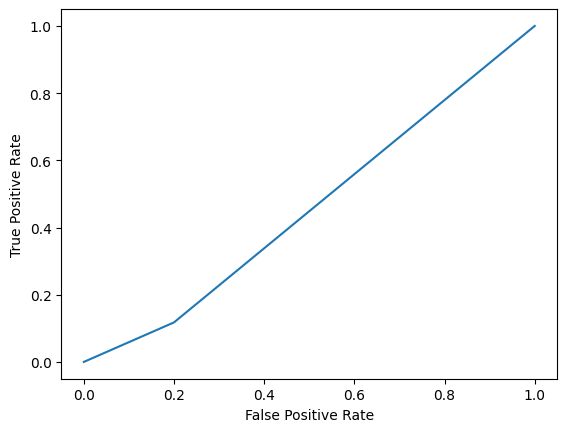

SAVE TURN OFF
RandomForestClassifier


None
Accuracy:0.630
Precision:0.818
Recall:  0.529
F1-score: 0.643

Confusion Matrix:
 [[8 2]
 [8 9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.80      0.62        10
           1       0.82      0.53      0.64        17

    accuracy                           0.63        27
   macro avg       0.66      0.66      0.63        27
weighted avg       0.70      0.63      0.63        27

F1-результаты по фолдам: [0.5        0.55555556 0.6        0.70588235 0.6       ]
Средний F1: 0.59


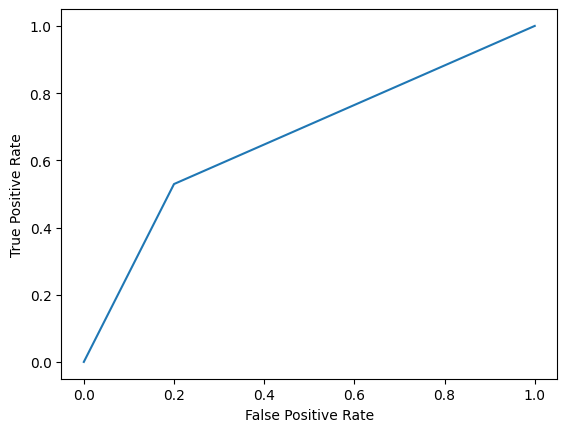

SAVE TURN OFF
GradientBoostingClassifier


Accuracy:0.519
Precision:0.833
Recall:  0.294
F1-score: 0.435

Confusion Matrix:
 [[ 9  1]
 [12  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.90      0.58        10
           1       0.83      0.29      0.43        17

    accuracy                           0.52        27
   macro avg       0.63      0.60      0.51        27
weighted avg       0.68      0.52      0.49        27

F1-результаты по фолдам: [0.625      0.66666667 0.26666667 0.66666667 0.47058824]
Средний F1: 0.54


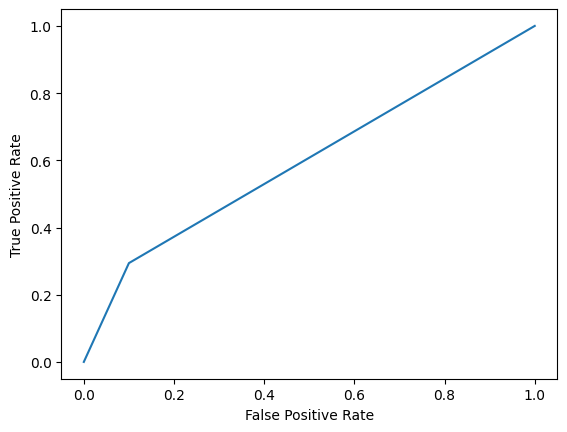

SAVE TURN OFF


In [6]:
EGG_balanced_data = tree_family("df_interacted[88,76].csv")
EGG_balanced_data.split_df_X_Y("здоров(1)/болен(0)")
EGG_balanced_data.split_train_test()
EGG_balanced_data.DecisionTreeClassifier(max_depth = 20,bool_save = False)
EGG_balanced_data.RandomForestClassifier(n_estimators= 200,max_depth = None,bool_save = False,min_samples_leaf = 5,max_features = "sqrt")
EGG_balanced_data.GradientBoostingClassifier(n_estimators = 300,max_depth = 20,bool_save = False)

Точность с PCA: 0.3333333333333333
Количество отобранных компонент: 32
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         9
           1       0.33      0.33      0.33         9

    accuracy                           0.33        18
   macro avg       0.33      0.33      0.33        18
weighted avg       0.33      0.33      0.33        18

Средний F1-score (macro): 0.3333
Матрица ошибок:
[[3 6]
 [6 3]]
F1-score на каждом фолде: [0.66666667 0.41558442 0.5        0.55       0.88888889 0.55
 0.55       0.55       0.46666667 0.87301587]
Средний F1: 0.6011
Стандартное отклонение: 0.1530
Средний F1: 0.6011
Средняя Accuracy: 0.6153


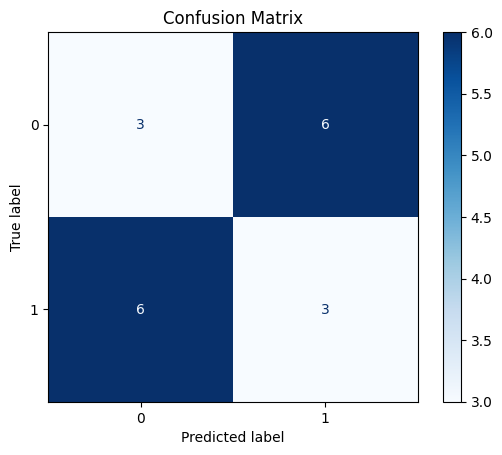

In [7]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import cross_validate

# Загрузка
df = pd.read_csv('df_interacted[88,76].csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Создаем пайплайн
pipe = Pipeline([
    ('scaler', StandardScaler()), # Центрируем данные (среднее=0, дисперсия=1)
    ('pca', PCA(n_components=0.9)), # Сохраняем компоненты, описывающие 80% дисперсии
    ('rf', RandomForestClassifier(n_estimators=300,
                                   n_jobs=-1,
                                   random_state=42,
                                   max_depth = 10,
                                   min_samples_leaf=4
                                   ))
])

pipe.fit(X_train, y_train)

print(f"Точность с PCA: {pipe.score(X_test, y_test)}")
print(f"Количество отобранных компонент: {pipe.named_steps['pca'].n_components_}")


from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Получаем предсказания на тестовых данных
y_pred = pipe.predict(X_test)

# 2. Выводим отчет о классификации (Precision, Recall, F1 для каждого класса)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred))

# 3. Считаем средний F1-score (поскольку вы упоминали его ранее)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Средний F1-score (macro): {f1:.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

# Настраиваем стратегию разбиения (например, на 5 частей)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Считаем метрики
# Мы передаем весь X и y, так как функция сама разделит их внутри
cv_results = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro')

print(f"F1-score на каждом фолде: {cv_results}")
print(f"Средний F1: {cv_results.mean():.4f}")
print(f"Стандартное отклонение: {cv_results.std():.4f}")
scoring = ['f1_macro', 'accuracy', 'precision_macro', 'recall_macro']
results = cross_validate(pipe, X, y, cv=skf, scoring=scoring)

print(f"Средний F1: {results['test_f1_macro'].mean():.4f}")
print(f"Средняя Accuracy: {results['test_accuracy'].mean():.4f}")

# 5. Визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [8]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# 1. Загрузка данных
df = pd.read_csv('df_interacted[88,76].csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Разделяем на трейн и тест (тест оставляем только для финальной проверки)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Создаем пайплайн с SVC
# Используем kernel='rbf' (нелинейное ядро), оно лучше всего находит сложные зависимости
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()), 
    ('svc', SVC(probability=True, random_state=42))
])

# 3. Настраиваем сетку параметров для поиска лучшей модели
# Мы будем искать оптимальное количество компонент PCA и параметры SVC
param_grid = {
    'pca__n_components': [5, 10, 15, 20,25,30,40,50,60,70,80,90,95,100], # Сильно уменьшаем кол-во признаков, чтобы убрать шум
    'svc__C': [0.1, 1, 10, 100],           # Регуляризация (штраф за ошибки)
    'svc__gamma': ['scale', 'auto', 0.01, 0.1] # Насколько далеко распространяется влияние одного примера
}

# Используем StratifiedKFold для надежности
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe_svc, param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

# 4. Результаты
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший средний F1 на кросс-валидации: {grid.best_score_:.4f}")

# Проверка на отложенном тесте
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nОтчет на тестовой выборке:")
print(classification_report(y_test, y_pred))

# Проверка стабильности на всех данных (финальная метрика)
final_cv = cross_val_score(best_model, X, y, cv=skf, scoring='f1_macro')
print(f"\nИтоговая стабильность (средний F1 по всей базе): {final_cv.mean():.4f} (+/- {final_cv.std():.4f})")

Лучшие параметры: {'pca__n_components': 5, 'svc__C': 10, 'svc__gamma': 'scale'}
Лучший средний F1 на кросс-валидации: 0.6035

Отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.62      0.56      0.59         9

    accuracy                           0.61        18
   macro avg       0.61      0.61      0.61        18
weighted avg       0.61      0.61      0.61        18


Итоговая стабильность (средний F1 по всей базе): 0.5541 (+/- 0.1937)


Точность с PCA: 0.4444444444444444
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.45      0.56      0.50         9
           1       0.43      0.33      0.38         9

    accuracy                           0.44        18
   macro avg       0.44      0.44      0.44        18
weighted avg       0.44      0.44      0.44        18

Средний F1-score (macro): 0.4375
Матрица ошибок:
[[5 4]
 [6 3]]


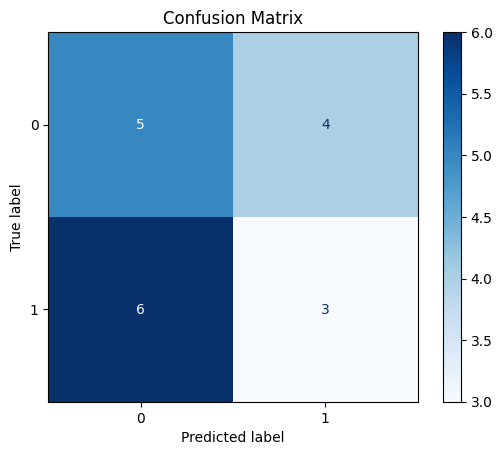

In [9]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

# Загрузка
df = pd.read_csv('df_interacted.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



# Используем ваш лучший RF внутри RFE
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
selector = RFE(rf_selector, n_features_to_select=20, step=10) # Оставить 20 лучших признаков

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))
])
pipe.fit(X_train, y_train)

print(f"Точность с PCA: {pipe.score(X_test, y_test)}")
#print(f"Количество отобранных компонент: {pipe.named_steps['pca'].n_components_}")


from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Получаем предсказания на тестовых данных
y_pred = pipe.predict(X_test)

# 2. Выводим отчет о классификации (Precision, Recall, F1 для каждого класса)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred))

# 3. Считаем средний F1-score (поскольку вы упоминали его ранее)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Средний F1-score (macro): {f1:.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

# 5. Визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [10]:
from sklearn.model_selection import GridSearchCV

# Настраиваем сетку ТАК, чтобы она обязательно включала ваши параметры (10 деревьев, глубина 5)
param_grid = {
    'pca__n_components': [0.75, 0.8, 0.85, 0.9], 
    'rf__n_estimators': [100,200,300,400,500],        # Добавляем малые значения как у вас
    'rf__max_depth': [5, 8, 10, None],            # Включаем глубину 5
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__criterion': ['gini', 'entropy']          # Проверяем разные способы оценки разделения
}

# Используем GridSearchCV для ГАРАНТИРОВАННОГО обхода всех комбинаций
grid_search = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Новые лучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1 на кросс-валидации: {grid_search.best_score_:.4f}")

# Сравнение с тестом
best_model = grid_search.best_estimator_
print(f"Точность на тесте: {best_model.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


ValueError: Invalid parameter 'pca' for estimator Pipeline(steps=[('scaler', StandardScaler()),
                ('selector',
                 RFE(estimator=RandomForestClassifier(max_depth=5,
                                                      random_state=42),
                     n_features_to_select=20, step=10)),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

Точность с PCA: 0.4444444444444444
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44         9
           1       0.44      0.44      0.44         9

    accuracy                           0.44        18
   macro avg       0.44      0.44      0.44        18
weighted avg       0.44      0.44      0.44        18

Средний F1-score (macro): 0.4444
Матрица ошибок:
[[4 5]
 [5 4]]


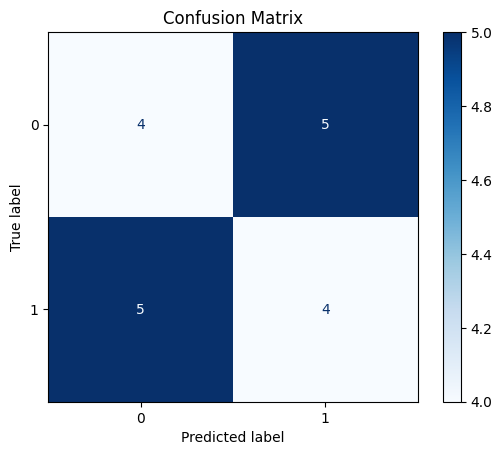

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectKBest, f_classif
# Загрузка
df = pd.read_csv('df_balanced.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)




pipe = Pipeline([
    ('scaler', StandardScaler()),
    # Выбираем 20 самых статистически значимых связей вместо PCA
    ('selector', SelectKBest(score_func=f_classif, k=10)), 
    ('clf', CatBoostClassifier(iterations=500, learning_rate=0.03, depth=6, verbose=0))
])

pipe.fit(X_train, y_train)

print(f"Точность с PCA: {pipe.score(X_test, y_test)}")
#print(f"Количество отобранных компонент: {pipe.named_steps['pca'].n_components_}")


from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Получаем предсказания на тестовых данных
y_pred = pipe.predict(X_test)

# 2. Выводим отчет о классификации (Precision, Recall, F1 для каждого класса)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred))

# 3. Считаем средний F1-score (поскольку вы упоминали его ранее)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Средний F1-score (macro): {f1:.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

# 5. Визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


Точность с PCA: 0.6111111111111112
Количество отобранных компонент: 39
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.62      0.56      0.59         9

    accuracy                           0.61        18
   macro avg       0.61      0.61      0.61        18
weighted avg       0.61      0.61      0.61        18

F1-score на каждом фолде: [0.6625     0.625      0.64935065 0.58245614 0.48484848]
Средний F1: 0.6008
Стандартное отклонение: 0.0641
Средний F1: 0.6008
Средняя Accuracy: 0.6235
Матрица ошибок:
[[6 3]
 [4 5]]


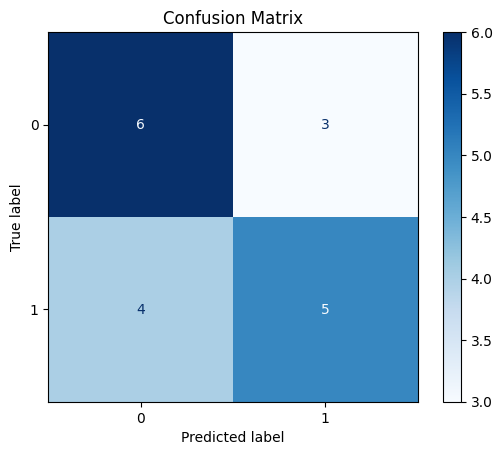

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
# Загрузка
df = pd.read_csv('df_balanced.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Замените RF в пайплайне на CatBoost
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.85)),
    ('clf', CatBoostClassifier(iterations=10000, learning_rate=0.002, depth=6, verbose=0))
])

pipe.fit(X_train, y_train)

print(f"Точность с PCA: {pipe.score(X_test, y_test)}")
print(f"Количество отобранных компонент: {pipe.named_steps['pca'].n_components_}")


from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Получаем предсказания на тестовых данных
y_pred = pipe.predict(X_test)

# 2. Выводим отчет о классификации (Precision, Recall, F1 для каждого класса)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred))

cv_results = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro')

print(f"F1-score на каждом фолде: {cv_results}")
print(f"Средний F1: {cv_results.mean():.4f}")
print(f"Стандартное отклонение: {cv_results.std():.4f}")
scoring = ['f1_macro', 'accuracy', 'precision_macro', 'recall_macro']
results = cross_validate(pipe, X, y, cv=skf, scoring=scoring)

print(f"Средний F1: {results['test_f1_macro'].mean():.4f}")
print(f"Средняя Accuracy: {results['test_accuracy'].mean():.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

# 5. Визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


Финальная точность на тесте: 0.6667

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.64      0.78      0.70         9
           1       0.71      0.56      0.62         9

    accuracy                           0.67        18
   macro avg       0.68      0.67      0.66        18
weighted avg       0.68      0.67      0.66        18

F1-score на каждом фолде: [0.60990712 0.53246753 0.72136223 0.51428571 0.64583333]
Средний F1: 0.6048
Стандартное отклонение: 0.0758
Средний F1: 0.5613
Средняя Accuracy: 0.5680


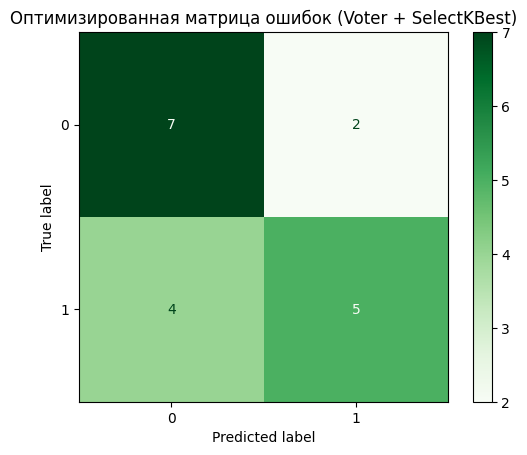

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Подготовка данных
df = pd.read_csv('df_interacted.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Настройка ансамбля (Voter)
# Используем лучшие параметры, которые мы нашли ранее
clf1 = CatBoostClassifier(iterations=6000, learning_rate=0.003, depth=6, verbose=0)
clf2 = RandomForestClassifier(n_estimators=400, max_depth=None, random_state=42)
clf3 = SVC(probability=True, kernel='rbf', C=1.0) # RBF ядро часто лучше для био-данных

voter = VotingClassifier(
    estimators=[('cat', clf1), ('rf', clf2), ('svc', clf3)],
    voting='soft'
)

# 3. Исправленный Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    # Попробуем k=15, это "золотая середина" для такого количества данных
    ('pca', PCA(n_components=0.9)), 
    ('clf', voter) # ОБЯЗАТЕЛЬНО кортеж ('имя', объект)
])

# 4. Обучение и оценка
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print(f"Финальная точность на тесте: {pipe.score(X_test, y_test):.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))

cv_results = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro')

print(f"F1-score на каждом фолде: {cv_results}")
print(f"Средний F1: {cv_results.mean():.4f}")
print(f"Стандартное отклонение: {cv_results.std():.4f}")
scoring = ['f1_macro', 'accuracy', 'precision_macro', 'recall_macro']
results = cross_validate(pipe, X, y, cv=skf, scoring=scoring)

print(f"Средний F1: {results['test_f1_macro'].mean():.4f}")
print(f"Средняя Accuracy: {results['test_accuracy'].mean():.4f}")

# Визуализация
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Greens)
plt.title("Оптимизированная матрица ошибок (Voter + SelectKBest)")
plt.show()

Финальная точность на тесте: 0.6667

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.71      0.56      0.62         9
           1       0.64      0.78      0.70         9

    accuracy                           0.67        18
   macro avg       0.68      0.67      0.66        18
weighted avg       0.68      0.67      0.66        18



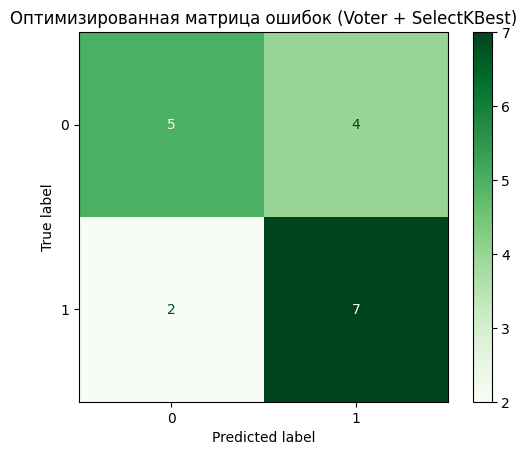

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# 1. Подготовка данных
df = pd.read_csv('df_balanced.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



# 1. Увеличиваем сложность моделей в ансамбле
clf1 = CatBoostClassifier(iterations=500, learning_rate=0.04, depth=6, verbose=0)
clf2 = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
# RBF ядро и настройка C помогают лучше разделять сложные случаи
clf3 = SVC(probability=True, kernel='rbf', C=10.0, gamma='scale') 

voter = VotingClassifier(
    estimators=[('cat', clf1), ('rf', clf2), ('svc', clf3)],
    voting='soft'
)

# 2. Оставляем почти всю дисперсию (0.99)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.999)), 
    ('clf', voter)
])

pipe.fit(X_train, y_train)

# 4. Обучение и оценка
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print(f"Финальная точность на тесте: {pipe.score(X_test, y_test):.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))

# Визуализация
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Greens)
plt.title("Оптимизированная матрица ошибок (Voter + SelectKBest)")
plt.show()

In [ ]:
df = pd.read_csv(r"combined_horizontal_data.csv")

Точность с PCA: 0.7368421052631579
Количество отобранных компонент: 51
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.44      0.44      0.44         9

    accuracy                           0.74        38
   macro avg       0.64      0.64      0.64        38
weighted avg       0.74      0.74      0.74        38

Средний F1-score (macro): 0.6360
Матрица ошибок:
[[24  5]
 [ 5  4]]


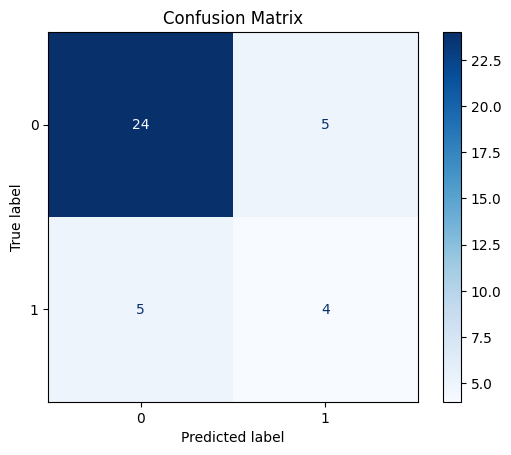

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Загрузка
df = pd.read_csv(r"combined_horizontal_data.csv")
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Создаем пайплайн
pipe = Pipeline([
    ('scaler', StandardScaler()), # Центрируем данные (среднее=0, дисперсия=1)
    ('pca', PCA(n_components=0.80)), # Сохраняем компоненты, описывающие 95% дисперсии
    ('rf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42,class_weight= {0:1,1:10}))
])

pipe.fit(X_train, y_train)

print(f"Точность с PCA: {pipe.score(X_test, y_test)}")
print(f"Количество отобранных компонент: {pipe.named_steps['pca'].n_components_}")

from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Получаем предсказания на тестовых данных
y_pred = pipe.predict(X_test)

# 2. Выводим отчет о классификации (Precision, Recall, F1 для каждого класса)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred))

# 3. Считаем средний F1-score (поскольку вы упоминали его ранее)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Средний F1-score (macro): {f1:.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

# 5. Визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

DecisionTreeClassifier


Accuracy:0.750
Precision:0.429
Recall:  0.500
F1-score: 0.462

Confusion Matrix:
 [[36  8]
 [ 6  6]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84        44
           1       0.43      0.50      0.46        12

    accuracy                           0.75        56
   macro avg       0.64      0.66      0.65        56
weighted avg       0.77      0.75      0.76        56

F1-результаты по фолдам: [0.5        0.4        0.7        0.33333333 0.22222222]
Средний F1: 0.43


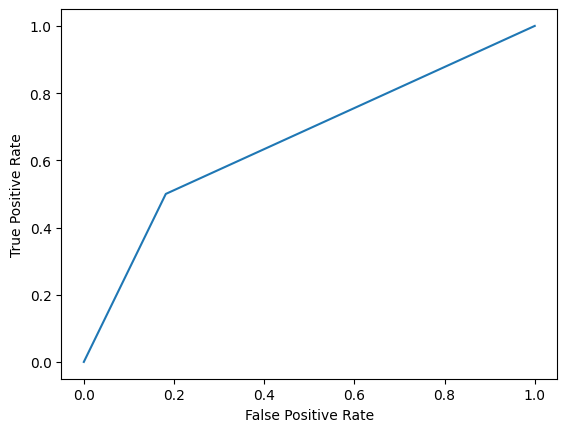

SAVE TURN OFF
RandomForestClassifier


100
Accuracy:0.821
Precision:0.750
Recall:  0.250
F1-score: 0.375

Confusion Matrix:
 [[43  1]
 [ 9  3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.98      0.90        44
           1       0.75      0.25      0.38        12

    accuracy                           0.82        56
   macro avg       0.79      0.61      0.64        56
weighted avg       0.81      0.82      0.78        56

F1-результаты по фолдам: [0.18181818 0.2        0.         0.         0.2       ]
Средний F1: 0.12


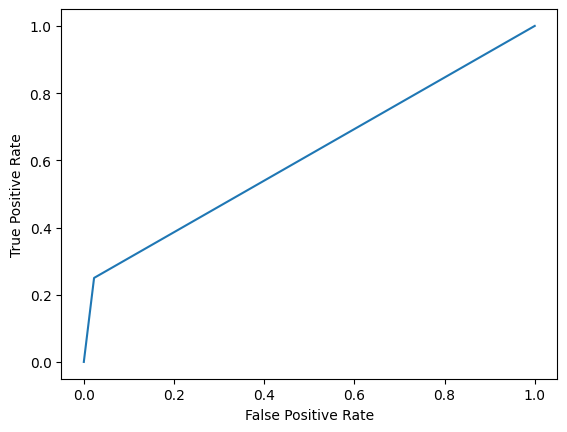

SAVE TURN OFF


In [ ]:
EGG_data = tree_family(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\combined_horizontal_data.csv")
EGG_data.split_df_X_Y("здоров(1)/болен(0)")
EGG_data.split_train_test()
EGG_data.DecisionTreeClassifier(max_depth = 200,bool_save = False,class_weight= {0:1,1:4})
EGG_data.RandomForestClassifier(n_estimators= 10,max_depth = 100,bool_save = False,class_weight= {0:1,1:4},max_features='sqrt')
# EGG_data.GradientBoostingClassifier(n_estimators = 300,max_depth = 200,bool_save = False)

In [ ]:
df = pd.read_csv(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\df_with_new_1_category_EEG.csv")
x = df.drop("здоров(1)/болен(0)",axis=1)
y = df["здоров(1)/болен(0)"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=None,random_state=42)

In [ ]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, x_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-16 17:14:17,894] A new study created in memory with name: no-name-a3c93efe-3fea-4293-9013-fe7defcb6a42
[I 2026-04-16 17:14:18,263] Trial 0 finished with value: 0.8083333333333332 and parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8083333333333332.
[I 2026-04-16 17:14:18,471] Trial 1 finished with value: 0.7121794871794871 and parameters: {'max_depth': 20, 'min_samples_leaf': 20, 'min_samples_split': 13, 'criterion': 'gini'}. Best is trial 0 with value: 0.8083333333333332.
[I 2026-04-16 17:14:18,839] Trial 2 finished with value: 0.8083333333333332 and parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 9, 'cr

Best params: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 7, 'criterion': 'entropy'}
Best score: 0.8233333333333335


In [ ]:
df = pd.read_csv(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\combined_horizontal_data.csv")
x = df.drop("здоров(1)/болен(0)",axis=1)
y = df["здоров(1)/болен(0)"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=None,random_state=42)
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, x_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-04-16 17:17:19,739] A new study created in memory with name: no-name-fa9879e0-0350-4d59-b8a4-57620e91adea
[I 2026-04-16 17:17:19,874] Trial 0 finished with value: 0.8076923076923077 and parameters: {'max_depth': 14, 'min_samples_leaf': 22, 'min_samples_split': 15, 'criterion': 'gini'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-04-16 17:17:20,075] Trial 1 finished with value: 0.7923076923076923 and parameters: {'max_depth': 10, 'min_samples_leaf': 12, 'min_samples_split': 7, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-04-16 17:17:20,222] Trial 2 finished with value: 0.8076923076923077 and parameters: {'max_depth': 9, 'min_samples_leaf': 15, 'min_samples_split': 20, 'criterion': 'gini'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-04-16 17:17:20,339] Trial 3 finished with value: 0.7846153846153846 and parameters: {'max_depth': 13, 'min_samples_leaf': 26, 'min_samples_split': 7, 'criterion': 'gini'}. Best is trial 0 wi

Best params: {'max_depth': 4, 'min_samples_leaf': 22, 'min_samples_split': 14, 'criterion': 'entropy'}
Best score: 0.8615384615384615


In [ ]:
class StackingEnsemble:
    """
    Универсальный стекинг ансамбль для классификации и регрессии
    """
    
    def __init__(self, 
                 base_models: List,
                 meta_model,
                 n_folds: int = 5,
                 use_probas: bool = False,
                 regression: bool = False,
                 random_state: int = 42):
        """
        Параметры:
        -----------
        base_models: список базовых моделей
        meta_model: мета-модель (финальный блендер)
        n_folds: количество фолдов для кросс-валидации
        use_probas: использовать вероятности (для классификации)
        regression: True для регрессии, False для классификации
        random_state: random seed
        """
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
        self.use_probas = use_probas
        self.regression = regression
        self.random_state = random_state
        self.base_models_trained = []
        self.meta_model_trained = None
        self.feature_names = None
        
    def fit(self, X, y):
        """
        Обучение стекинг ансамбля
        """
        X = np.array(X)
        y = np.array(y)
        
        # Сохраняем названия признаков если есть
        if hasattr(X, 'columns'):
            self.feature_names = list(X.columns)
        
        # Матрица для предсказаний базовых моделей
        n_samples = X.shape[0]
        
        if self.regression:
            n_meta_features = len(self.base_models)
        else:
            if self.use_probas:
                n_classes = len(np.unique(y))
                n_meta_features = len(self.base_models) * n_classes
            else:
                n_meta_features = len(self.base_models)
        
        meta_features = np.zeros((n_samples, n_meta_features))
        
        # Обучение базовых моделей с кросс-валидацией
        print("Обучение базовых моделей...")
        kf = self._get_kfold()
        
        for i, model in enumerate(self.base_models):
            print(f"  Модель {i+1}/{len(self.base_models)}: {type(model).__name__}")
            
            # Создаем копию модели для обучения
            model_clone = self._clone_model(model)
            self.base_models_trained.append(model_clone)
            
            # Полное обучение модели на всех данных
            model_clone.fit(X, y)
            
            # Кросс-валидация для получения out-of-fold предсказаний
            fold_predictions = np.zeros(n_samples)
            
            for train_idx, val_idx in kf.split(X, y):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train = y[train_idx]
                
                # Обучаем на фолде
                fold_model = self._clone_model(model)
                fold_model.fit(X_train, y_train)
                
                # Предсказываем на валидационном фолде
                if self.regression:
                    pred = fold_model.predict(X_val)
                else:
                    if self.use_probas:
                        pred = fold_model.predict_proba(X_val)
                        # Для бинарной классификации берем вероятность положительного класса
                        if pred.shape[1] == 2:
                            pred = pred[:, 1]
                        else:
                            # Для многоклассовой - все вероятности
                            pred = pred.reshape(-1, n_classes)
                    else:
                        pred = fold_model.predict(X_val)
                
                fold_predictions[val_idx] = pred
            
            # Сохраняем out-of-fold предсказания как фичи для мета-модели
            if self.regression:
                meta_features[:, i] = fold_predictions
            else:
                if self.use_probas:
                    if len(fold_predictions.shape) == 1:
                        meta_features[:, i] = fold_predictions
                    else:
                        start_idx = i * n_classes
                        end_idx = (i + 1) * n_classes
                        meta_features[:, start_idx:end_idx] = fold_predictions
                else:
                    meta_features[:, i] = fold_predictions
        
        # Обучение мета-модели на предсказаниях базовых моделей
        print("\nОбучение мета-модели...")
        self.meta_model_trained = self._clone_model(self.meta_model)
        self.meta_model_trained.fit(meta_features, y)
        
        return self
    
    def predict(self, X):
        """
        Предсказание стекинг ансамбля
        """
        X = np.array(X)
        
        # Получаем предсказания от базовых моделей
        base_predictions = self._get_base_predictions(X)
        
        # Предсказание мета-модели
        final_prediction = self.meta_model_trained.predict(base_predictions)
        
        return final_prediction
    
    def predict_proba(self, X):
        """
        Предсказание вероятностей (для классификации)
        """
        if self.regression:
            raise ValueError("Метод predict_proba доступен только для классификации")
        
        X = np.array(X)
        base_predictions = self._get_base_predictions(X)
        
        if hasattr(self.meta_model_trained, 'predict_proba'):
            return self.meta_model_trained.predict_proba(base_predictions)
        else:
            raise ValueError("Мета-модель не поддерживает predict_proba")
    
    def _get_base_predictions(self, X):
        """
        Получение предсказаний от всех базовых моделей
        """
        n_samples = X.shape[0]
        
        if self.regression:
            n_meta_features = len(self.base_models)
        else:
            if self.use_probas:
                n_classes = len(np.unique(
                    self.base_models_trained[0].classes_ 
                    if hasattr(self.base_models_trained[0], 'classes_') 
                    else np.unique([model.predict(X) for model in self.base_models_trained])
                ))
                n_meta_features = len(self.base_models) * n_classes
            else:
                n_meta_features = len(self.base_models)
        
        base_predictions = np.zeros((n_samples, n_meta_features))
        
        for i, model in enumerate(self.base_models_trained):
            if self.regression:
                pred = model.predict(X)
                base_predictions[:, i] = pred
            else:
                if self.use_probas:
                    pred_proba = model.predict_proba(X)
                    if pred_proba.shape[1] == 2:
                        base_predictions[:, i] = pred_proba[:, 1]
                    else:
                        start_idx = i * n_classes
                        end_idx = (i + 1) * n_classes
                        base_predictions[:, start_idx:end_idx] = pred_proba
                else:
                    pred = model.predict(X)
                    base_predictions[:, i] = pred
        
        return base_predictions
    
    def _get_kfold(self):
        """Создание стратегии кросс-валидации"""
        if self.regression:
            return KFold(n_splits=self.n_folds, shuffle=True, 
                        random_state=self.random_state)
        else:
            return StratifiedKFold(n_splits=self.n_folds, shuffle=True, 
                                 random_state=self.random_state)
    
    def _clone_model(self, model):
        """Клонирование модели"""
        from sklearn.base import clone
        return clone(model)
    
    def get_feature_importances(self):
        """
        Получение важности фичей от мета-модели
        """
        if hasattr(self.meta_model_trained, 'feature_importances_'):
            return self.meta_model_trained.feature_importances_
        elif hasattr(self.meta_model_trained, 'coef_'):
            return np.abs(self.meta_model_trained.coef_).mean(axis=0)
        else:
            return None
    
    def get_model_weights(self):
        """
        Получение весов моделей в ансамбле
        """
        importances = self.get_feature_importances()
        if importances is not None:
            model_weights = {}
            n_models = len(self.base_models)
            
            if self.regression or not self.use_probas:
                for i, model in enumerate(self.base_models):
                    model_name = type(model).__name__
                    model_weights[model_name] = importances[i] if i < len(importances) else 0
            else:
                # Для многоклассовой классификации с вероятностями
                n_classes = len(self.base_models_trained[0].classes_)
                for i, model in enumerate(self.base_models):
                    model_name = type(model).__name__
                    start_idx = i * n_classes
                    end_idx = (i + 1) * n_classes
                    model_weights[model_name] = np.mean(importances[start_idx:end_idx])
            
            return model_weights
        return None

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
def create_classification_stack():
    """
    Создание стекинг ансамбля для классификации
    """
    # Базовые модели
    base_models = [
        RandomForestClassifier(n_estimators=100, random_state=42),
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, 
                     eval_metric='logloss'),
        LGBMClassifier(n_estimators=100, random_state=42),
        SVC(probability=True, random_state=42),
        KNeighborsClassifier(n_neighbors=7),
        GaussianNB(),
        MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
    ]
    
    # Мета-модель
    meta_model = LogisticRegression(random_state=42, max_iter=1000)
    
    # Создаем стекинг ансамбль
    stack = StackingEnsemble(
        base_models=base_models,
        meta_model=meta_model,
        n_folds=5,
        use_probas=True,
        regression=False,
        random_state=42
    )
    
    return stack
